# Modelo

Para ver como cambia la performance del modelo con el tratamiento de los datos primero hay que tener un modelo de partida que optimizar.

In [ ]:
import numpy as np
import pandas as pd
import os
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import randint, uniform, norm, loguniform

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, classification_report, confusion_matrix, roc_auc_score

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

from transformers import Resampler, BandPassFilter, SpectralSubtractor, MelSpectrogramTransformer, SpectrogramPadder, FlattenTransformer, FeatureExtractor, WaveletDenoiser

from config import SEED

Elegimos dataset

In [ ]:
dataset = 'ciclos_f2_r'

## Espectrogramas

Se suelen usar Mel espectrogramas

Traigo los consjuntos de entrenamiento y testeo. (TODO: buscar una manera más eficiente de guardarlos)

In [ ]:
train_data = np.load(f'./dataset/{dataset}/train_melspectrogram.npz')
X_train = train_data['X']
y_train = train_data['y']

test_data = np.load(f'./dataset/{dataset}/test_melspectrogram.npz')
X_test = test_data['X']
y_test = test_data['y']

In [10]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1435, 23808), (1435,), (359, 23808), (359,))

### Random Forest

#### Entrenamiento

In [ ]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

param_distributions = {
    'max_depth': randint(8, 20),
    'min_samples_split': randint(5, 25),
    'min_samples_leaf': randint(5, 25)
}

el scoring podría ser recall 

In [9]:
rnd_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=50,
    scoring='recall',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    verbose=3,
    random_state=SEED
)

rnd_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 1/5] END max_depth=14, min_samples_leaf=13, min_samples_split=22;, score=0.608 total time=   1.5s
[CV 2/5] END max_depth=14, min_samples_leaf=13, min_samples_split=22;, score=0.685 total time=   1.5s
[CV 3/5] END max_depth=14, min_samples_leaf=13, min_samples_split=22;, score=0.729 total time=   1.4s
[CV 4/5] END max_depth=14, min_samples_leaf=13, min_samples_split=22;, score=0.646 total time=   1.5s
[CV 5/5] END max_depth=14, min_samples_leaf=13, min_samples_split=22;, score=0.611 total time=   1.6s
[CV 1/5] END max_depth=14, min_samples_leaf=20, min_samples_split=17;, score=0.587 total time=   1.4s
[CV 2/5] END max_depth=14, min_samples_leaf=20, min_samples_split=17;, score=0.692 total time=   1.3s
[CV 3/5] END max_depth=14, min_samples_leaf=20, min_samples_split=17;, score=0.715 total time=   1.4s
[CV 4/5] END max_depth=14, min_samples_leaf=20, min_samples_split=17;, score=0.625 total time=   1.4s
[CV 5/5] END max_dep

,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': <scipy.stats....00140EB807B60>, 'min_samples_leaf': <scipy.stats....00140EB90C550>, 'min_samples_split': <scipy.stats....00140EB7A3C50>}"
,n_iter,50
,scoring,'recall'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,3
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [11]:
pd.DataFrame(rnd_search.cv_results_)[['param_max_depth', 'param_min_samples_leaf', 'param_min_samples_split', 'mean_test_score']].sort_values(by='mean_test_score', ascending=False).head(20)

,param_max_depth,param_min_samples_leaf,param_min_samples_split,mean_test_score
28,11,11,23,0.675466
32,11,11,19,0.669959
47,10,10,20,0.667123
26,14,12,23,0.662937
42,12,10,18,0.660159
31,14,11,19,0.658790
20,9,13,18,0.658751
23,12,11,13,0.657401
18,12,12,16,0.657382
5,12,13,17,0.657343


In [12]:
print("Best params:", rnd_search.best_params_)
print("Best CV score:", rnd_search.best_score_)

best_model = rnd_search.best_estimator_

Best params: {'max_depth': 11, 'min_samples_leaf': 11, 'min_samples_split': 23}
Best CV score: 0.6754662004662004


In [13]:
y_pred = best_model.predict(X_train)
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95       717
           1       0.97      0.92      0.95       718

    accuracy                           0.95      1435
   macro avg       0.95      0.95      0.95      1435
weighted avg       0.95      0.95      0.95      1435



#### Evaluación

In [14]:
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.88      0.82       180
           1       0.86      0.73      0.79       179

    accuracy                           0.80       359
   macro avg       0.81      0.80      0.80       359
weighted avg       0.81      0.80      0.80       359



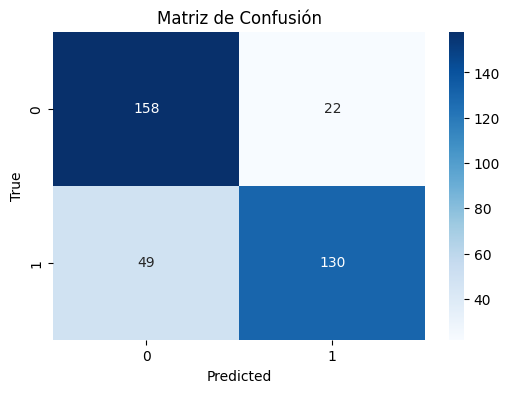

In [15]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Matriz de Confusión');

#### Guardado

In [ ]:
joblib.dump(best_model, f'./modelos/{dataset}/melspec_rf.pkl')

['./modelos/ciclos_f2_r/melspec_rf.pkl']

## Atributos de Audio

1. Resample y Filtro pasa bajos
2. Feature Extractor
    + MFCC (13)
    + ZCR
    + Short-Time Energy
    + SC
    + Spectral Roll-off
    + BER
    + Spectral Flatness
3. Scaler

In [ ]:
train_data = np.load(f'./dataset/{dataset}/train_features.npz')
X_train = train_data['X']
y_train = train_data['y']

test_data = np.load(f'./dataset/{dataset}/test_features.npz')
X_test = test_data['X']
y_test = test_data['y']

In [21]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1435, 19), (1435,), (359, 19), (359,))

### Random Forest

#### Entrenamiento

In [22]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

param_distributions = {
    'max_depth': randint(5, 20),
    'min_samples_split': randint(5, 25),
    'min_samples_leaf': randint(5, 25)
}

In [23]:
rnd_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=100,
    scoring='recall',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    verbose=3,
    random_state=SEED
)

rnd_search.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5] END max_depth=11, min_samples_leaf=24, min_samples_split=19;, score=0.566 total time=   0.3s
[CV 2/5] END max_depth=11, min_samples_leaf=24, min_samples_split=19;, score=0.636 total time=   0.2s
[CV 3/5] END max_depth=11, min_samples_leaf=24, min_samples_split=19;, score=0.625 total time=   0.2s
[CV 4/5] END max_depth=11, min_samples_leaf=24, min_samples_split=19;, score=0.632 total time=   0.2s
[CV 5/5] END max_depth=11, min_samples_leaf=24, min_samples_split=19;, score=0.611 total time=   0.2s
[CV 1/5] END max_depth=15, min_samples_leaf=12, min_samples_split=11;, score=0.650 total time=   0.2s
[CV 2/5] END max_depth=15, min_samples_leaf=12, min_samples_split=11;, score=0.720 total time=   0.2s
[CV 3/5] END max_depth=15, min_samples_leaf=12, min_samples_split=11;, score=0.681 total time=   0.2s
[CV 4/5] END max_depth=15, min_samples_leaf=12, min_samples_split=11;, score=0.667 total time=   0.2s
[CV 5/5] END max_de

,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': <scipy.stats....00140EB9E8050>, 'min_samples_leaf': <scipy.stats....00140EB9C5910>, 'min_samples_split': <scipy.stats....00140EB9E9F30>}"
,n_iter,100
,scoring,'recall'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,3
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [24]:
pd.DataFrame(rnd_search.cv_results_)[['param_max_depth', 'param_min_samples_leaf', 'param_min_samples_split', 'mean_test_score']].sort_values(by='mean_test_score', ascending=False).head(10)

,param_max_depth,param_min_samples_leaf,param_min_samples_split,mean_test_score
66,18,6,16,0.713102
40,18,7,5,0.708926
77,13,5,12,0.706129
3,15,8,12,0.704769
54,13,7,11,0.700544
91,18,7,20,0.699165
92,18,7,22,0.697815
73,17,7,24,0.696387
74,16,8,23,0.696368
29,12,5,16,0.695027


In [25]:
print("Best params:", rnd_search.best_params_)
print("Best CV score:", rnd_search.best_score_)

best_model = rnd_search.best_estimator_

Best params: {'max_depth': 18, 'min_samples_leaf': 6, 'min_samples_split': 16}
Best CV score: 0.7131021756021757


In [26]:
y_pred = best_model.predict(X_train)
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94       717
           1       0.96      0.91      0.94       718

    accuracy                           0.94      1435
   macro avg       0.94      0.94      0.94      1435
weighted avg       0.94      0.94      0.94      1435



#### Evaluación

In [27]:
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.90      0.85       180
           1       0.89      0.79      0.83       179

    accuracy                           0.84       359
   macro avg       0.85      0.84      0.84       359
weighted avg       0.85      0.84      0.84       359



#### Guardado

In [28]:
joblib.dump(best_model, f'./modelos/ciclos_f2_r/features_rf.pkl')

['./modelos/ciclos_f2_r/features_rf.pkl']